📘  THEORY

🔷 1.What is Statistical Distributions?

A statistical distribution shows how data values are spread or distributed.
It describes the probability of different outcomes of a random variable.
Examples include normal, binomial, and Poisson distributions.

    
🔷 2.What is a Q-Q Plot and why is it used?

A Q-Q (Quantile-Quantile) plot compares two distributions.
It helps check if data follows a normal distribution.
If points lie on a straight line, distributions are similar.

    
🔷 3.. Difference between Discrete and Continuous Distributions

Discrete distributions deal with countable values (e.g., 0,1,2).
Continuous distributions deal with infinite values in a range.
Discrete uses PMF, while continuous uses PDF.


🔷 4.What is Bernoulli Distribution?

It is a distribution with only two outcomes: success or failure.
Each trial has probability 
𝑝
p for success.
Example: coin toss (Head or Tail).

    
🔷 5.What is Binomial Distribution?

It gives probability of successes in multiple trials.
Each trial is independent with same probability 𝑝
Example: number of heads in 10 coin tosses. 


🔷 6. Explain Log-Normal Distribution

A variable is log-normal if its logarithm is normally distributed.
It is used for positive-valued data like income or stock prices.
The distribution is skewed to the right.


🔷 7.Explain Power Law Distribution
    
It shows that small values are common and large values are rare.
Follows relation: 
𝑃(𝑥)∝𝑥−𝑘P(x)∝x−k.
Used in networks, wealth distribution, etc. 

    
🔷 8.What is Box-Cox Transform?
    
It is a transformation used to make data normal.
It stabilizes variance and improves model performance.
Common in regression analysis.

    
🔷 9.Explain Poisson Distribution with an example
    
It models number of events in fixed time/space.
Events occur independently at a constant rate.
Example: number of calls received in an hour.

    
🔷 10.What is Z-score Probability?
    
Z-score measures how far a value is from mean in standard deviations.
It is used in normal distribution.
Helps find probability using Z-tables. 

    
🔷 11.differentiate probability density function (pdf) and cumulative distribution function (cdf)
    
PDF shows probability density at a point, while CDF gives cumulative probability up to that point.
CDF is integral of PDF, and PDF is derivative of CDF.
CDF ranges from 0 to 1, while total area under PDF is 1.

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [18]:
df = pd.read_excel(r"C:\Users\Dell\Downloads\spread_locator_dataset.xlsx")

# Check data
print(df.head())
print(df.info())

                         transaction_id customer_id  transaction_amount  \
0  e98aa092-3770-4fdb-9502-5b5a6a244811    CUST2824             3821.34   
1  11ba6918-dba0-41e5-96cf-f5a7b95f0103    CUST1409             2781.84   
2  82b7654b-6eb7-4579-89a0-1a9edec0a7bb    CUST5506             4120.97   
3  f7166574-f400-4d53-b526-0b11f6619ddf    CUST5012             6383.78   
4  8632fe26-b507-4068-9c68-1b2fa04fecb3    CUST4657             2651.61   

  transaction_date  transaction_count region transaction_status  
0       2023-01-26                  3  North               Fail  
1       2023-01-28                  0   East               Fail  
2       2023-01-28                  0  South               Fail  
3       2023-01-18                  2  South            Success  
4       2023-01-04                  4  North            Success  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 220 entries, 0 to 219
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype   

Bernoulli Probability: 0.7818181818181819


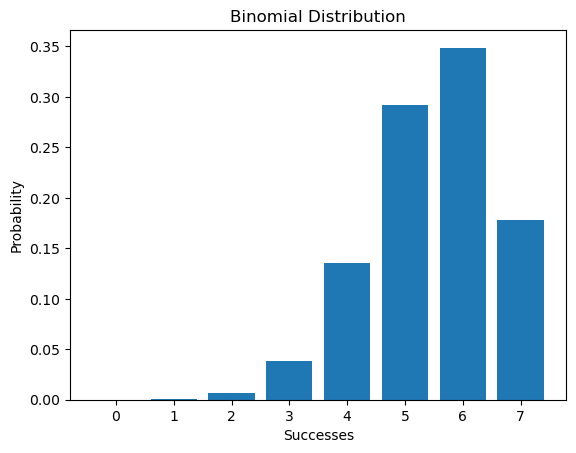

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binom

# Bernoulli (0 or 1)
df['occurrence'] = np.where(df['transaction_amount'] > 2000, 1, 0)

p = df['occurrence'].mean()
print("Bernoulli Probability:", p)

# Binomial (weekly = 7 days)
n = 7
x = np.arange(0, n+1)
y = binom.pmf(x, n, p)

plt.bar(x, y)
plt.title("Binomial Distribution")
plt.xlabel("Successes")
plt.ylabel("Probability")
plt.show()

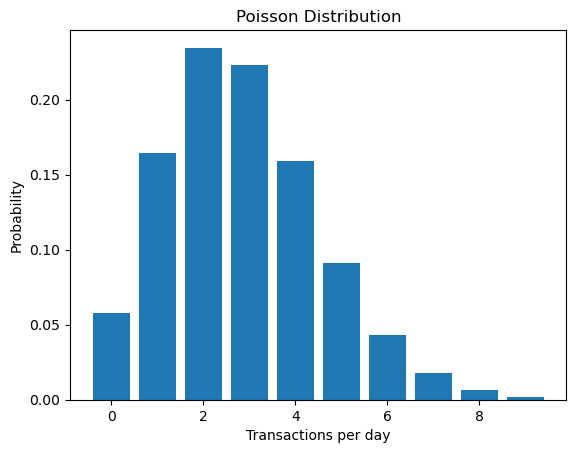

In [11]:
from scipy.stats import poisson

mean_val = df['transaction_count'].mean()

x = np.arange(0, 10)
y = poisson.pmf(x, mean_val)

plt.bar(x, y)
plt.title("Poisson Distribution")
plt.xlabel("Transactions per day")
plt.ylabel("Probability")
plt.show()

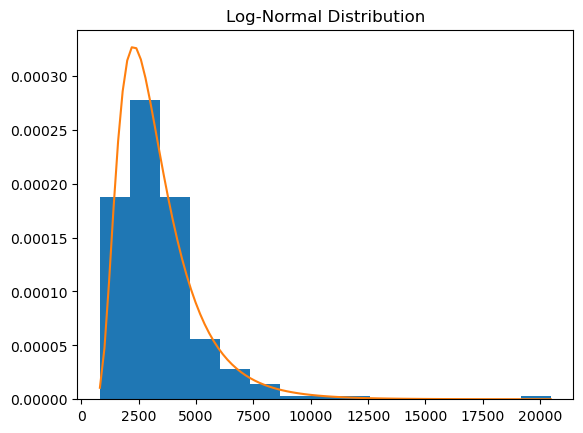

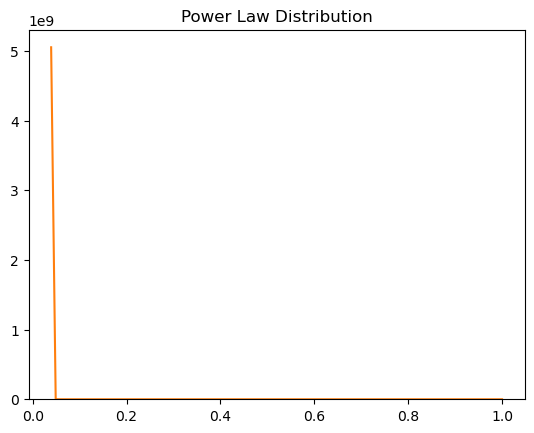

In [12]:
from scipy.stats import lognorm, powerlaw
import numpy as np

data = df['transaction_amount']
data = data[data > 0]  # remove zero if any

# Log-normal
shape, loc, scale = lognorm.fit(data)
x = np.linspace(data.min(), data.max(), 100)

plt.hist(data, bins=15, density=True)
plt.plot(x, lognorm.pdf(x, shape, loc, scale))
plt.title("Log-Normal Distribution")
plt.show()

# Power law
data_norm = data / data.max()

a, loc, scale = powerlaw.fit(data_norm)
x2 = np.linspace(data_norm.min(), data_norm.max(), 100)

plt.hist(data_norm, bins=15, density=True)
plt.plot(x2, powerlaw.pdf(x2, a, loc, scale))
plt.title("Power Law Distribution")
plt.show()

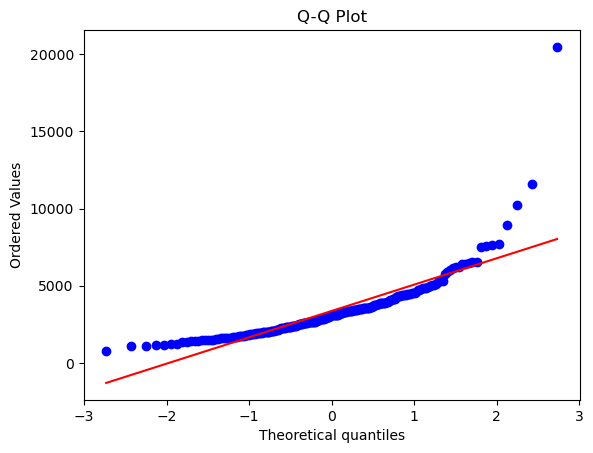

In [13]:
from scipy import stats

stats.probplot(df['transaction_amount'], dist="norm", plot=plt)
plt.title("Q-Q Plot")
plt.show()

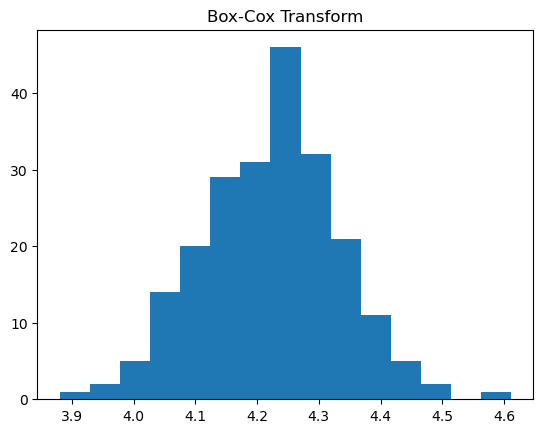

In [14]:
from scipy.stats import boxcox

data = df['transaction_amount']
data = data[data > 0]  # required

transformed, _ = boxcox(data)

plt.hist(transformed, bins=15)
plt.title("Box-Cox Transform")
plt.show()

In [15]:
# Z-score
mean = df['transaction_amount'].mean()
std = df['transaction_amount'].std()

df['z_score'] = (df['transaction_amount'] - mean) / std

print(df[['transaction_amount', 'z_score']].head())

# Probability > 5000
prob = (df['transaction_amount'] > 5000).mean()
print("Probability > 5000:", prob)

   transaction_amount   z_score
0             3821.34  0.229716
1             2781.84 -0.293776
2             4120.97  0.380609
3             6383.78  1.520159
4             2651.61 -0.359360
Probability > 5000: 0.11363636363636363


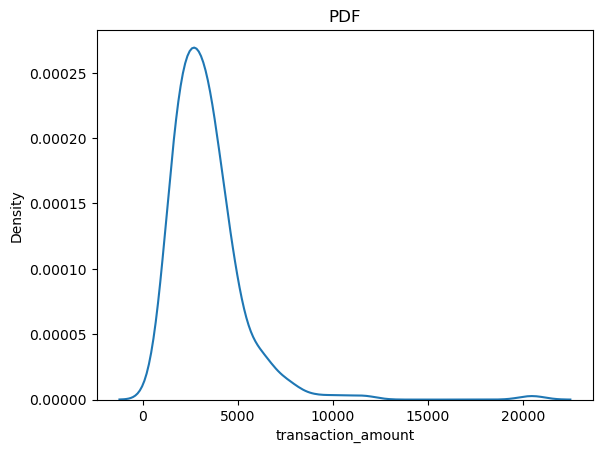

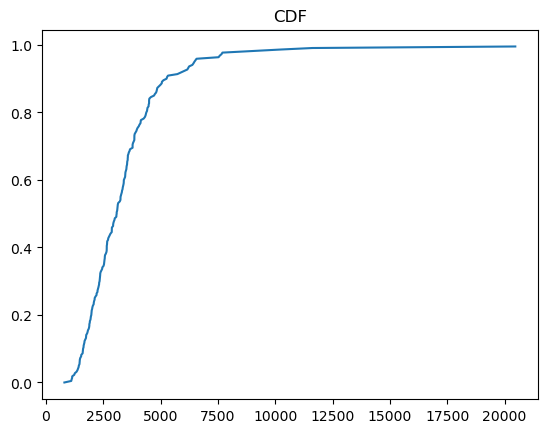

In [16]:
import seaborn as sns
import numpy as np

# PDF
sns.kdeplot(df['transaction_amount'])
plt.title("PDF")
plt.show()

# CDF
data = np.sort(df['transaction_amount'])
cdf = np.arange(len(data)) / len(data)

plt.plot(data, cdf)
plt.title("CDF")
plt.show()

🔷  Conclusion 

Transaction data is right-skewed

Q-Q plot shows data is not normal

Log-normal distribution fits best

Power law explains extreme high values

High-value transactions (>₹5000) are rare

This helps in fraud detection and financial decision-making